# Q3 · Where is a battery worth the most?

A battery can buy power when it is cheap and sell it when it is dear. This notebook estimates what that
**day-ahead arbitrage** could have earned, per zone and year, for a 1 MW battery.

Reads the dbt mart `fct_battery_arbitrage`, built from a linear program solved for every zone and local day
([ADR-007](../control-room/04%20Decisions/ADR-007%20Battery%20Arbitrage%20Model.md)):

- 1 MW battery, 1, 2 (default) or 4 hours of storage; 88% round-trip efficiency; at most 1 full cycle a day;
  empty at the start and end of each local day.
- Cleared day-ahead prices at their native resolution (hourly, 15-min from 1 Oct 2025); price-taker.

**Read these numbers as an upper bound for one market, not a business case.** The model has perfect foresight
of the day's cleared prices, which no real bidder has. It leaves out intraday, balancing and capacity markets
(often the larger part of a real battery's income), degradation, grid fees, and all costs. This is not
investment advice: no IRR or payback is computed.

In [1]:
import sys

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

import chart_style as cs

sys.path.insert(0, str(cs.REPO_ROOT))  # for models.battery
from models.battery import Battery, optimal_day

cs.apply_style()

with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    q3 = con.sql("select * from fct_battery_arbitrage order by zone, local_year, battery_duration_h").df()
    q1 = con.sql("select zone, local_year, negative_hours, avg_price from fct_negative_hours").df()
    ytd_end = con.sql("select as_of_date from int_as_of").fetchone()[0]
    ytd = con.sql("select * from fct_ytd_comparison order by zone, local_year").df()

CURRENT_YEAR = 2026
# Every 2026 number runs to the run's as-of date (int_as_of), the same for all zones.
YTD_LABEL = f"1 Jan to {ytd_end:%-d %b} 2026"
WINDOW = f"1 Jan to {ytd_end:%-d %b}"
IT_NOTE = "North Italy: offers below 0 €/MWh are not allowed on its day-ahead market (GME), so prices cannot go negative."
CAVEAT = ("Upper bound: perfect foresight, day-ahead only (no intraday, balancing or capacity markets, "
          "degradation or grid fees).")
k_eur = mticker.FuncFormatter(lambda v, _: f"€{v / 1000:.0f}k")
two_h = q3[q3.battery_duration_h == 2]
usable = two_h[(~two_h.is_partial_year) | (two_h.partial_reason == "current_year")]  # drops PL 2019 (PLN)
print("2026 year to date:", YTD_LABEL)
two_h[["zone", "local_year", "revenue_eur_per_mw", "avg_daily_revenue_eur_per_mw", "avg_spread_captured_eur_mwh",
       "cycles", "negative_revenue_share", "heuristic_revenue_eur_per_mw", "lp_uplift", "coverage", "partial_reason"]]

2026 year to date: 1 Jan to 2 Oct 2026


,zone,local_year,revenue_eur_per_mw,avg_daily_revenue_eur_per_mw,avg_spread_captured_eur_mwh,cycles,negative_revenue_share,heuristic_revenue_eur_per_mw,lp_uplift,coverage,partial_reason
1,BE,2019,16572.0,45.53,27.77,364.0,0.080609,14816.0,0.118554,0.99726,NaN
4,BE,2020,17208.0,47.02,27.61,366.0,0.070247,14757.0,0.166078,1.00000,NaN
7,BE,2021,45021.0,123.35,75.09,365.0,0.030753,37005.0,0.216615,1.00000,NaN
10,BE,2022,107719.0,295.12,178.87,365.0,0.018017,85264.0,0.263364,1.00000,NaN
13,BE,2023,51210.0,140.30,82.75,365.0,0.026159,42013.0,0.218922,1.00000,NaN
...,...,...,...,...,...,...,...,...,...,...,...
178,PT,2022,47111.0,129.07,87.20,360.4,0.000000,39504.0,0.192562,1.00000,NaN
181,PT,2023,39241.0,107.51,65.31,365.0,0.000000,32771.0,0.197440,1.00000,NaN
184,PT,2024,41009.0,112.05,64.48,366.0,0.000643,33731.0,0.215754,1.00000,NaN
187,PT,2025,58915.0,161.41,89.68,365.0,0.001541,50636.0,0.163502,1.00000,NaN


## Chart 1 · 2025 revenue per MW by zone, 2-hour battery
Bars: the optimal schedule (LP). Tick: the rule of thumb (charge in the cheapest 2 hours, discharge in the most
expensive 2) on the same prices.

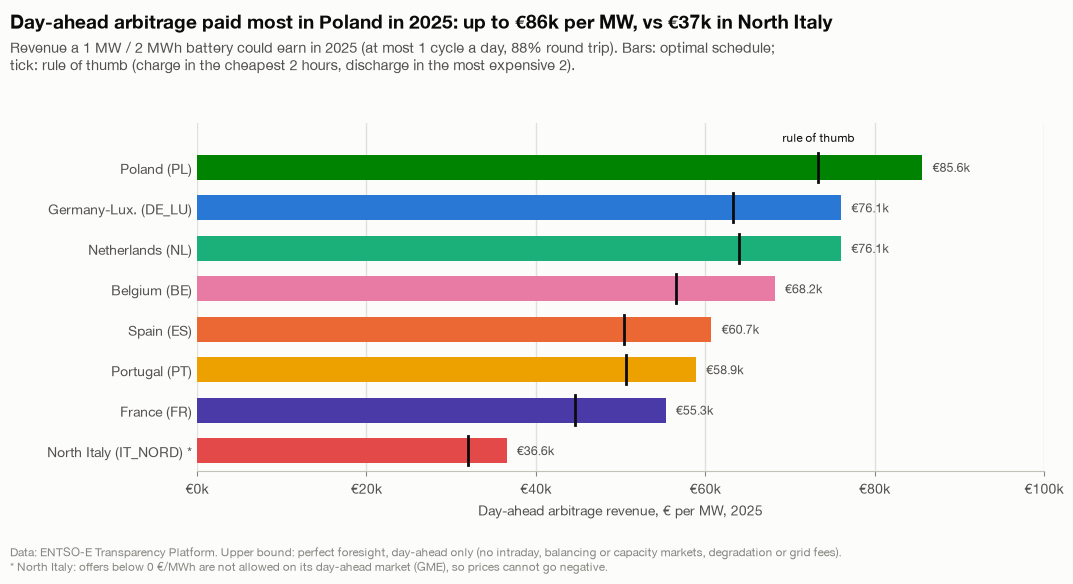

In [2]:
c1 = usable[usable.local_year == 2025].sort_values("revenue_eur_per_mw", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.subplots_adjust(left=0.18, right=0.95, top=0.79, bottom=0.19)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
for i, r in c1.iterrows():
    ax.barh(i, r.revenue_eur_per_mw, height=0.62, color=cs.ZONE_COLORS[r.zone], zorder=2)
    ax.plot([r.heuristic_revenue_eur_per_mw] * 2, [i - 0.36, i + 0.36], color=cs.INK, lw=2, zorder=3)
    ax.text(r.revenue_eur_per_mw + 1200, i, f"€{r.revenue_eur_per_mw / 1000:.1f}k", ha="left", va="center",
            fontsize=9, color=cs.INK_SECONDARY)
ax.set_yticks(range(len(c1)), [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z == "IT_NORD" else "") for z in c1.zone])
ax.set_ylim(len(c1) - 0.5, -1.1)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(k_eur)
ax.set_xlim(0, 100_000)
ax.set_xlabel("Day-ahead arbitrage revenue, € per MW, 2025")
ax.spines["bottom"].set_color(cs.AXIS)
top = c1.iloc[0]
ax.annotate("rule of thumb", (top.heuristic_revenue_eur_per_mw, -0.36), xytext=(0, 6),
            textcoords="offset points", ha="center", va="bottom", fontsize=8.5, color=cs.INK)

lo, hi = c1.iloc[-1], c1.iloc[0]
cs.add_title(
    fig,
    f"Day-ahead arbitrage paid most in {cs.ZONE_LABELS[hi.zone]} in 2025: up to €{hi.revenue_eur_per_mw / 1000:.0f}k "
    f"per MW, vs €{lo.revenue_eur_per_mw / 1000:.0f}k in {cs.ZONE_LABELS[lo.zone]}",
    "Revenue a 1 MW / 2 MWh battery could earn in 2025 (at most 1 cycle a day, 88% round trip). Bars: optimal "
    "schedule;\ntick: rule of thumb (charge in the cheapest 2 hours, discharge in the most expensive 2).",
)
cs.add_source(fig, CAVEAT + "\n* " + IT_NOTE)
cs.save(fig, "q3_revenue_by_zone_2025")
plt.show()

### How much of 2026 comes from 15-minute prices?
Since 1 Oct 2025 the day-ahead market clears in 15-minute periods, and the battery trades them. Re-solve every
2026 day on **hourly averages** of the same prices: the difference is what the finer resolution adds. 2026 to date is
compared with the **same window of 2025** (hourly prices except 1 and 2 Oct 2025), never with a full year.

In [3]:
with duckdb.connect(str(cs.WAREHOUSE), read_only=True) as con:
    hourly = con.sql('''
        select p.zone, p.local_date, date_trunc('hour', p.ts_utc) as hour_utc,
               sum(p.price_eur_mwh * p.duration_h) / sum(p.duration_h) as price,
               sum(p.duration_h) as hours
        from int_prices_local p
        semi join (select zone, local_date from battery.arbitrage_daily
                   where local_year = 2026 and battery_duration_h = 2) d using (zone, local_date)
        group by all order by p.zone, hour_utc''').df()

battery = Battery(duration_h=2)
hourly_rev = (hourly.groupby(["zone", "local_date"])
              .apply(lambda d: optimal_day(d.price.to_numpy(), d.hours.to_numpy(), battery).revenue_eur)
              .groupby("zone").sum())
by_year = usable.pivot(index="zone", columns="local_year", values="revenue_eur_per_mw")
window = ytd.pivot(index="zone", columns="local_year", values="battery_revenue_eur_per_mw")
res = window[[2025, CURRENT_YEAR]].rename(columns={2025: "ytd_2025", CURRENT_YEAR: "ytd_2026_15min"})
res["ytd_2026_hourly"] = hourly_rev.round(0)
res["added_by_15min"] = (res.ytd_2026_15min / res.ytd_2026_hourly - 1).round(6)
res["change_vs_2025_native"] = (res.ytd_2026_15min / res.ytd_2025 - 1).round(6)
res["change_vs_2025_hourly"] = (res.ytd_2026_hourly / res.ytd_2025 - 1).round(6)
res["days_2026"] = two_h[two_h.local_year == CURRENT_YEAR].set_index("zone").days_solved
# Saved next to the mart CSVs: the README and finding notes quote these numbers.
res.reset_index().to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q3_hourly_resolve_ytd.csv", index=False)
res.sort_values("added_by_15min")

local_year,ytd_2025,ytd_2026_15min,ytd_2026_hourly,added_by_15min,change_vs_2025_native,change_vs_2025_hourly,days_2026
zone,,,,,,,
PT,46162.0,59843.0,58637.0,0.020567,0.296369,0.270244,275
ES,47697.0,62771.0,61464.0,0.021264,0.316037,0.288635,275
DE_LU,63263.0,78911.0,75007.0,0.052048,0.247348,0.185638,275
NL,63832.0,78382.0,74041.0,0.058630,0.227942,0.159935,275
PL,70180.0,87529.0,82126.0,0.065789,0.247207,0.170219,275
BE,57808.0,73257.0,68539.0,0.068837,0.267247,0.185632,275
FR,43704.0,66218.0,61947.0,0.068946,0.515147,0.417422,275
IT_NORD,28874.0,40188.0,36588.0,0.098393,0.391840,0.267161,275


## Chart 2 · Revenue by zone, full years 2019 to 2025
Panels are ordered by 2025 revenue. 2026 is compared like for like in chart 2b. Poland 2019 is left out (prices in
PLN before 20 Nov 2019).

peak year per zone: {'BE': 2022, 'DE_LU': 2022, 'ES': 2025, 'FR': 2022, 'IT_NORD': 2022, 'NL': 2022, 'PL': 2025, 'PT': 2025}


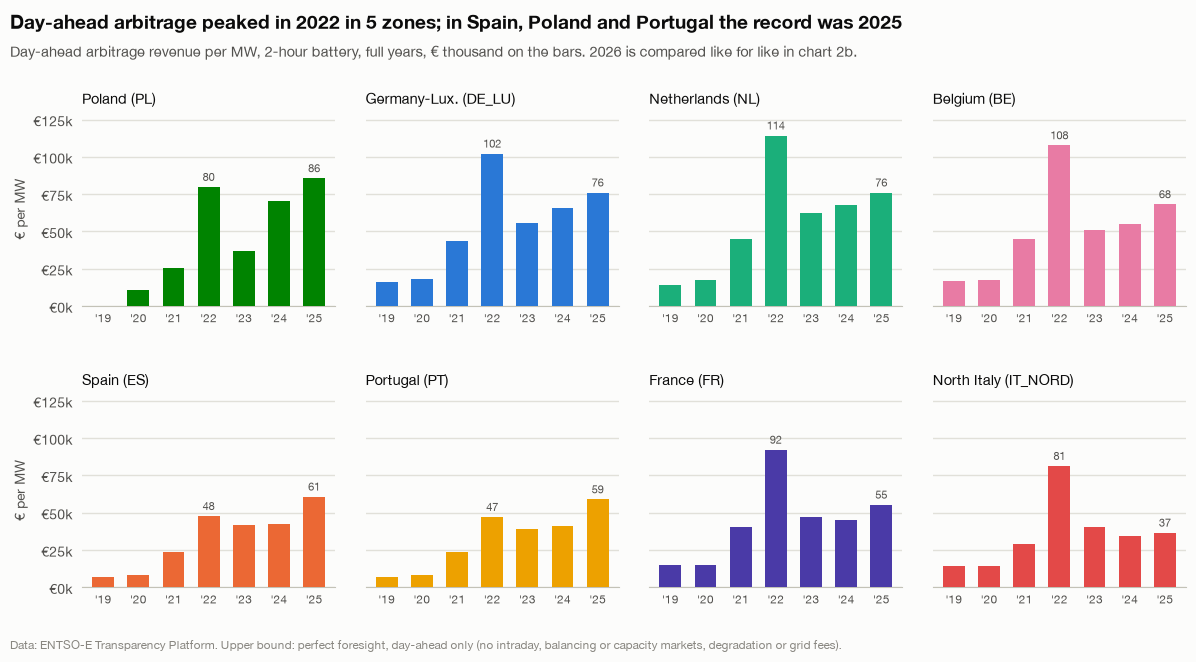

In [4]:
order = c1.zone.tolist()
years = list(range(2019, CURRENT_YEAR))
full = usable[usable.local_year < CURRENT_YEAR]

fig, axes = plt.subplots(2, 4, figsize=(12, 6.6), sharey=True)
fig.subplots_adjust(left=0.07, right=0.99, top=0.83, bottom=0.11, hspace=0.45, wspace=0.12)
for ax, zone in zip(axes.flat, order):
    color = cs.ZONE_COLORS[zone]
    z = full[full.zone == zone].set_index("local_year").reindex(years)
    for year, rev in z.revenue_eur_per_mw.items():
        if pd.notna(rev):
            ax.bar(year, rev, width=0.62, color=color, zorder=3)
    for year in (2022, 2025):
        rev = z.revenue_eur_per_mw.get(year)
        if pd.notna(rev):
            ax.text(year, rev + 2500, f"{rev / 1000:.0f}", ha="center", va="bottom", fontsize=8,
                    color=cs.INK_SECONDARY)
    ax.set_title(f"{cs.ZONE_LABELS[zone]} ({zone})", loc="left", fontsize=10.5, color=cs.INK, pad=6)
    ax.set_xticks(years, [f"'{y % 100:02d}" for y in years])
    ax.tick_params(axis="x", length=0, labelsize=8.5)
    ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)
    ax.set_ylim(0, 130_000)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(25_000))
    ax.yaxis.set_major_formatter(k_eur)
    ax.spines["bottom"].set_color(cs.AXIS)
for ax in axes[:, 0]:
    ax.set_ylabel("€ per MW")

full_years = full.pivot(index="zone", columns="local_year", values="revenue_eur_per_mw")
peak = full_years.idxmax(axis=1)
peak_2022 = sorted(peak.index[peak == 2022])
peak_2025 = sorted(peak.index[peak == 2025])
print("peak year per zone:", peak.to_dict())
cs.add_title(
    fig,
    f"Day-ahead arbitrage peaked in 2022 in {len(peak_2022)} zones; in "
    f"{', '.join(cs.ZONE_LABELS[z] for z in peak_2025[:-1])} and {cs.ZONE_LABELS[peak_2025[-1]]} the record was 2025",
    "Day-ahead arbitrage revenue per MW, 2-hour battery, full years, € thousand on the bars. "
    "2026 is compared like for like in chart 2b.",
)
cs.add_source(fig, CAVEAT)
cs.save(fig, "q3_revenue_by_zone_over_time")
plt.show()

## Chart 2b · 2026 to date vs the same window of 2025
Like for like: both years cut to 1 January to the as-of date. Ring: 2025. Dot: 2026 at native 15-min prices. Tick:
2026 re-solved on hourly averages, to compare at the same resolution as 2025.

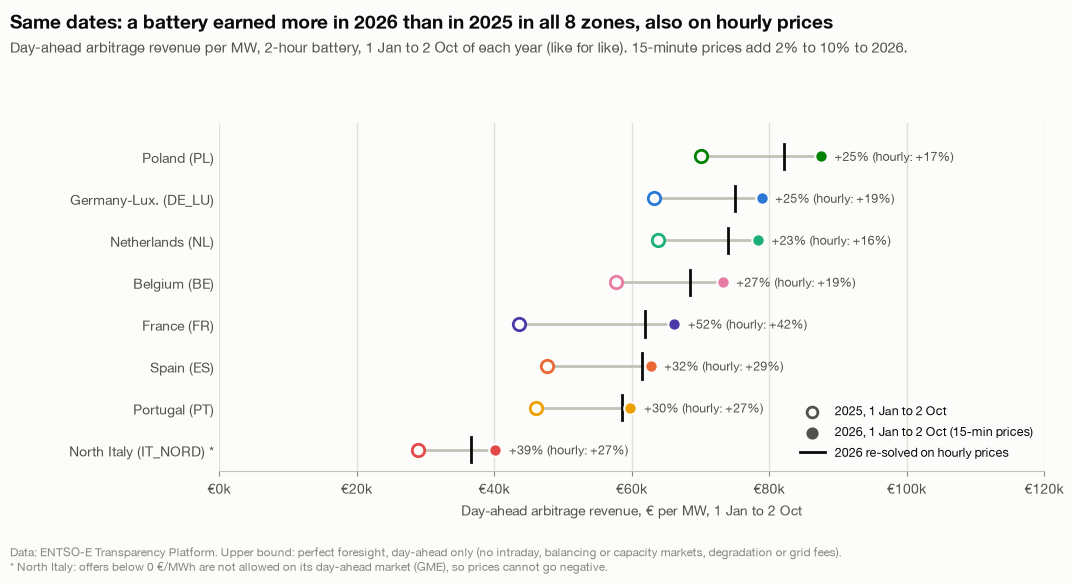

In [5]:
c2b = res.sort_values("ytd_2026_15min", ascending=False)
higher_native = int((c2b.change_vs_2025_native > 0).sum())
higher_hourly = int((c2b.change_vs_2025_hourly > 0).sum())

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.subplots_adjust(left=0.2, right=0.95, top=0.79, bottom=0.19)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
for i, (zone, r) in enumerate(c2b.iterrows()):
    color = cs.ZONE_COLORS[zone]
    ax.plot([r.ytd_2025, r.ytd_2026_15min], [i, i], color=cs.AXIS, lw=2, zorder=1)
    ax.scatter(r.ytd_2025, i, s=80, facecolor=cs.SURFACE, edgecolor=color, linewidth=2, zorder=3)
    ax.plot([r.ytd_2026_hourly] * 2, [i - 0.3, i + 0.3], color=cs.INK, lw=2, zorder=2)
    ax.scatter(r.ytd_2026_15min, i, s=80, color=color, edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    ax.text(r.ytd_2026_15min + 2000, i,
            f"+{r.change_vs_2025_native:.0%} (hourly: +{r.change_vs_2025_hourly:.0%})",
            ha="left", va="center", fontsize=9, color=cs.INK_SECONDARY)
ax.set_yticks(range(len(c2b)), [f"{cs.ZONE_LABELS[z]} ({z})" + (" *" if z == "IT_NORD" else "") for z in c2b.index])
ax.set_ylim(len(c2b) - 0.5, -0.8)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(k_eur)
ax.set_xlim(0, 120_000)
ax.set_xlabel(f"Day-ahead arbitrage revenue, € per MW, {WINDOW}")
ax.spines["bottom"].set_color(cs.AXIS)
ax.scatter([], [], s=60, facecolor=cs.SURFACE, edgecolor=cs.INK_SECONDARY, linewidth=2, label=f"2025, {WINDOW}")
ax.scatter([], [], s=60, color=cs.INK_SECONDARY, label=f"2026, {WINDOW} (15-min prices)")
ax.plot([], [], color=cs.INK, lw=2, label="2026 re-solved on hourly prices")
ax.legend(loc="lower right", frameon=False, fontsize=9)
assert higher_native == higher_hourly == 8, (higher_native, higher_hourly)
cs.add_title(
    fig,
    "Same dates: a battery earned more in 2026 than in 2025 in all 8 zones, also on hourly prices",
    f"Day-ahead arbitrage revenue per MW, 2-hour battery, {WINDOW} of each year (like for like). "
    f"15-minute prices add {res.added_by_15min.min():.0%} to {res.added_by_15min.max():.0%} to 2026.",
)
cs.add_source(fig, CAVEAT + "\n* " + IT_NOTE)
cs.save(fig, "q3_ytd_revenue")
plt.show()

## Chart 3 · Revenue vs negative hours (Q1 → Q3)
One dot per zone and full year (2019 to 2025), 2-hour battery. x: negative-price hours from Q1; y: arbitrage revenue.

r all = 0.40 (n=55), without 2022 = 0.76 (n=47)
within each year: {2019: np.float64(0.56), 2020: np.float64(0.78), 2021: np.float64(0.89), 2022: np.float64(0.77), 2023: np.float64(0.95), 2024: np.float64(0.63), 2025: np.float64(0.58)}


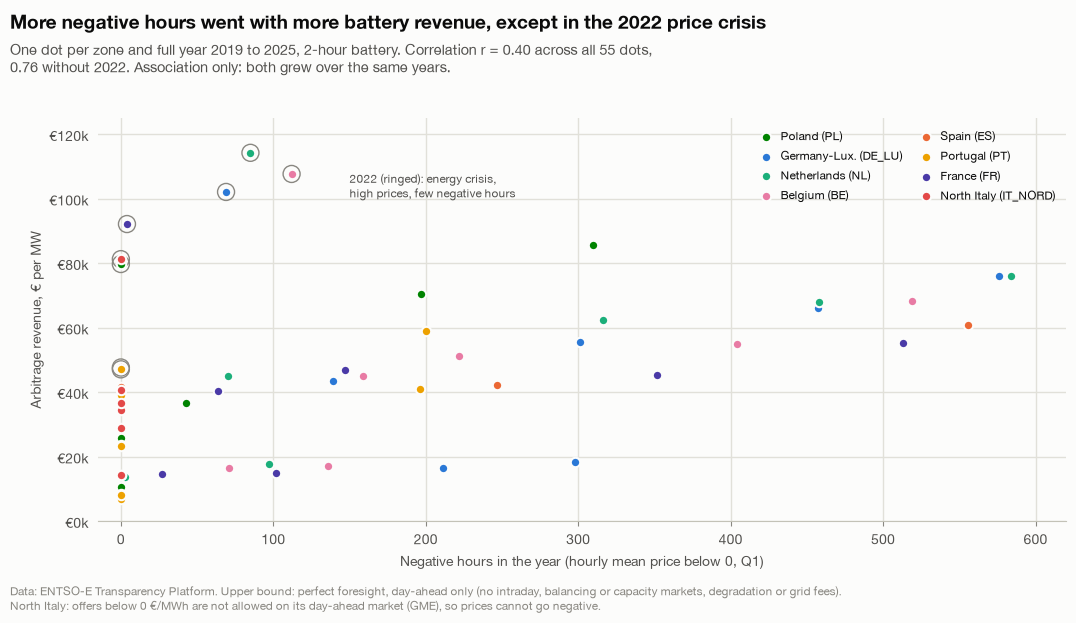

In [6]:
c3 = usable[usable.local_year < CURRENT_YEAR].merge(q1, on=["zone", "local_year"])
r_all = np.corrcoef(c3.negative_hours, c3.revenue_eur_per_mw)[0, 1]
no22 = c3[c3.local_year != 2022]
r_no22 = np.corrcoef(no22.negative_hours, no22.revenue_eur_per_mw)[0, 1]
within = {y: np.corrcoef(g.negative_hours, g.revenue_eur_per_mw)[0, 1] for y, g in c3.groupby("local_year")}
print(f"r all = {r_all:.2f} (n={len(c3)}), without 2022 = {r_no22:.2f} (n={len(no22)})")
print("within each year:", {y: round(r, 2) for y, r in within.items()})

fig, ax = plt.subplots(figsize=(11, 6.2))
fig.subplots_adjust(left=0.09, right=0.97, top=0.81, bottom=0.16)
ax.grid(axis="x", color=cs.GRID, lw=1)
for zone in order:
    z = c3[c3.zone == zone]
    ax.scatter(z.negative_hours, z.revenue_eur_per_mw, s=46, color=cs.ZONE_COLORS[zone],
               edgecolor=cs.SURFACE, linewidth=1.5, zorder=3, label=f"{cs.ZONE_LABELS[zone]} ({zone})")
y22 = c3[c3.local_year == 2022]
ax.scatter(y22.negative_hours, y22.revenue_eur_per_mw, s=150, facecolor="none", edgecolor=cs.INK_MUTED,
           linewidth=1, zorder=2)
ax.text(150, 104_000, "2022 (ringed): energy crisis,\nhigh prices, few negative hours",
        ha="left", va="center", fontsize=8.5, color=cs.INK_SECONDARY)
ax.set_xlabel("Negative hours in the year (hourly mean price below 0, Q1)")
ax.set_ylabel("Arbitrage revenue, € per MW")
ax.yaxis.set_major_formatter(k_eur)
ax.set_xlim(-15, 620)
ax.set_ylim(0, 125_000)
ax.spines["bottom"].set_color(cs.AXIS)
ax.legend(loc="upper right", frameon=False, fontsize=8.5, ncol=2, handletextpad=0.2, columnspacing=1)

cs.add_title(
    fig,
    "More negative hours went with more battery revenue, except in the 2022 price crisis",
    f"One dot per zone and full year 2019 to 2025, 2-hour battery. Correlation r = {r_all:.2f} across all "
    f"{len(c3)} dots,\n{r_no22:.2f} without 2022. Association only: both grew over the same years.",
)
cs.add_source(fig, CAVEAT + "\n" + IT_NOTE)
cs.save(fig, "q3_revenue_vs_negative_hours")
plt.show()

In [7]:
# Saved next to the mart CSVs: the README and finding notes quote these numbers.
corr = pd.DataFrame([{"scope": "all", "n": len(c3), "r": r_all}, {"scope": "without_2022", "n": len(no22), "r": r_no22}]
                    + [{"scope": str(y), "n": int((c3.local_year == y).sum()), "r": r} for y, r in within.items()])
corr.round(6).to_csv(cs.REPO_ROOT / "analysis" / "outputs" / "q3_negative_hours_correlation.csv", index=False)

### How much revenue comes from being paid to charge?
Share of the year's revenue that was money received for charging at negative prices (2-hour battery).

In [8]:
usable.pivot(index="zone", columns="local_year", values="negative_revenue_share").round(3)

local_year,2019,2020,2021,2022,2023,2024,2025,2026
zone,,,,,,,,
BE,0.081,0.070,0.031,0.018,0.026,0.060,0.069,0.055
DE_LU,0.082,0.112,0.026,0.001,0.039,0.043,0.050,0.059
ES,0.000,0.000,0.000,0.000,0.000,0.001,0.007,0.005
FR,0.009,0.043,0.014,0.000,0.012,0.043,0.038,0.061
IT_NORD,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
NL,0.001,0.031,0.016,0.016,0.077,0.069,0.057,0.053
PL,NaN,0.000,0.000,0.000,0.002,0.018,0.036,0.055
PT,0.000,0.000,0.000,0.000,0.000,0.001,0.002,0.004


## Chart 4 · How revenue grows with duration, 2025
One row per zone: revenue per MW for a 1-hour, 2-hour and 4-hour battery (same 1 MW of power, 1, 2 or 4 MWh of
storage). Zones are ordered by 4-hour revenue.

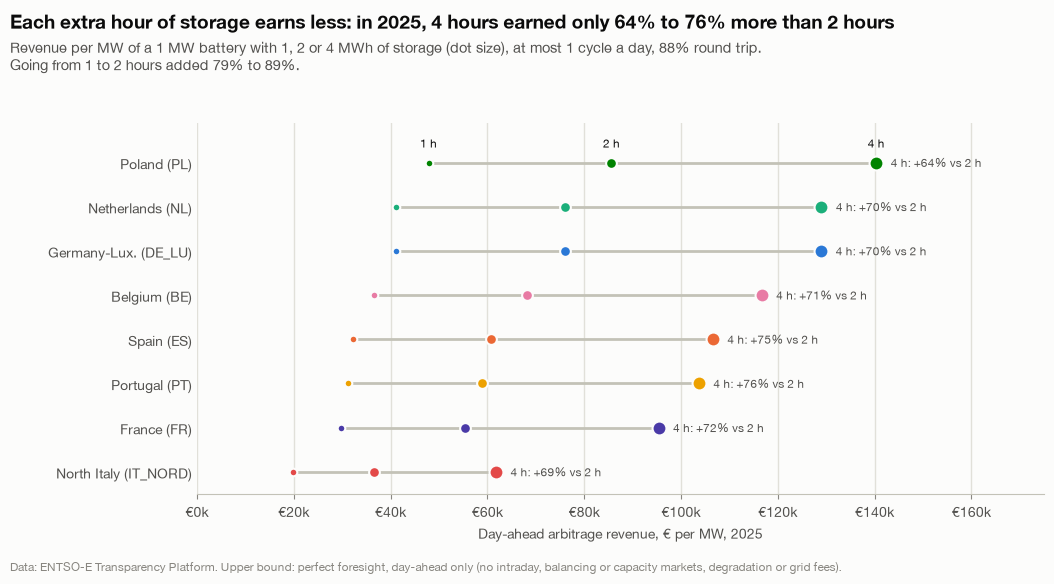

In [9]:
c4 = q3[q3.local_year == 2025].pivot(index="zone", columns="battery_duration_h", values="revenue_eur_per_mw")
c4 = c4.sort_values(4, ascending=False)
gain_2 = c4[2] / c4[1] - 1
gain_4 = c4[4] / c4[2] - 1

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.subplots_adjust(left=0.18, right=0.95, top=0.79, bottom=0.15)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=cs.GRID, lw=1)
sizes = {1: 30, 2: 60, 4: 100}
for i, (zone, r) in enumerate(c4.iterrows()):
    color = cs.ZONE_COLORS[zone]
    ax.plot([r[1], r[4]], [i, i], color=cs.AXIS, lw=2, zorder=1)
    for h in (1, 2, 4):
        ax.scatter(r[h], i, s=sizes[h], color=color, edgecolor=cs.SURFACE, linewidth=1.5, zorder=3)
    ax.text(r[4] + 3000, i, f"4 h: +{gain_4[zone]:.0%} vs 2 h", ha="left", va="center", fontsize=8.5,
            color=cs.INK_SECONDARY)
first = c4.iloc[0]
for h in (1, 2, 4):
    ax.annotate(f"{h} h", (first[h], 0), xytext=(0, 9), textcoords="offset points", ha="center", va="bottom",
                fontsize=8.5, color=cs.INK)
ax.set_yticks(range(len(c4)), [f"{cs.ZONE_LABELS[z]} ({z})" for z in c4.index])
ax.set_ylim(len(c4) - 0.5, -0.9)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.xaxis.set_major_formatter(k_eur)
ax.set_xlim(0, 175_000)
ax.set_xlabel("Day-ahead arbitrage revenue, € per MW, 2025")
ax.spines["bottom"].set_color(cs.AXIS)

cs.add_title(
    fig,
    f"Each extra hour of storage earns less: in 2025, 4 hours earned only {gain_4.min():.0%} to {gain_4.max():.0%} "
    "more than 2 hours",
    "Revenue per MW of a 1 MW battery with 1, 2 or 4 MWh of storage (dot size), at most 1 cycle a day, 88% round trip.\n"
    f"Going from 1 to 2 hours added {gain_2.min():.0%} to {gain_2.max():.0%}.",
    )
cs.add_source(fig, CAVEAT)
cs.save(fig, "q3_revenue_by_duration_2025")
plt.show()

In [10]:
# Saved next to the mart CSVs: the README and finding notes quote these numbers.
pd.DataFrame({"gain_2h_vs_1h": gain_2, "gain_4h_vs_2h": gain_4}).round(6).reset_index().to_csv(
    cs.REPO_ROOT / "analysis" / "outputs" / "q3_duration_gain_2025.csv", index=False)

## Benchmark
No published figure uses exactly these assumptions, so this is a sanity check, not a match (ADR-007):

- **Gridcog** (Mar 2025): a 1 MW / 2 h battery trading day-ahead only on 2024 German prices, "~70k" a year
  (cycles, efficiency and foresight not stated). This model: **DE_LU 2024, 2 h = €66,047/MW**.
- **Enervis BESS index** (Jan 2026): about €148,500/MW for Germany in 2025, for a 1 MW / 2 MWh battery trading
  intraday, FCR and aFRR at up to 1.5 cycles a day. Not comparable (other markets); this model's day-ahead-only
  DE_LU 2025 figure is €76,060, about half.

In [11]:
two_h[(two_h.zone == "DE_LU") & two_h.local_year.isin([2024, 2025])][
    ["zone", "local_year", "revenue_eur_per_mw", "avg_spread_captured_eur_mwh", "cycles"]]

,zone,local_year,revenue_eur_per_mw,avg_spread_captured_eur_mwh,cycles
40,DE_LU,2024,66047.0,101.14,366.0
43,DE_LU,2025,76060.0,116.15,364.9


## Numbers quoted in the findings

In [12]:
cols = ["zone", "local_year", "battery_duration_h", "revenue_eur_per_mw", "avg_daily_revenue_eur_per_mw",
        "avg_spread_captured_eur_mwh", "cycles", "negative_revenue_share", "heuristic_revenue_eur_per_mw", "lp_uplift"]
full = usable[usable.local_year < CURRENT_YEAR]
print("LP uplift over the rule of thumb, full years:", f"{full.lp_uplift.min():.1%} to {full.lp_uplift.max():.1%}")
q3[q3.local_year.isin([2022, 2025, 2026])][cols].sort_values(["local_year", "battery_duration_h", "zone"])

LP uplift over the rule of thumb, full years: 7.8% to 29.3%


,zone,local_year,battery_duration_h,revenue_eur_per_mw,avg_daily_revenue_eur_per_mw,avg_spread_captured_eur_mwh,cycles,negative_revenue_share,heuristic_revenue_eur_per_mw,lp_uplift
9,BE,2022,1,58211.0,159.48,190.83,365.0,0.020393,46026.0,0.264764
33,DE_LU,2022,1,54171.0,148.41,179.30,364.9,0.001139,41487.0,0.305735
57,ES,2022,1,25648.0,70.27,92.61,362.8,0.000000,21131.0,0.213768
81,FR,2022,1,49862.0,136.61,172.74,365.0,0.000030,41739.0,0.194610
105,IT_NORD,2022,1,43911.0,120.30,160.58,365.0,0.000000,40280.0,0.090142
...,...,...,...,...,...,...,...,...,...,...
95,FR,2026,4,116234.0,422.67,116.03,275.0,0.052163,96914.0,0.199350
119,IT_NORD,2026,4,67031.0,243.75,79.40,275.0,0.000000,58861.0,0.138813
143,NL,2026,4,134293.0,488.34,135.59,275.0,0.046108,114587.0,0.171975
167,PL,2026,4,146937.0,534.32,148.77,275.0,0.047597,128287.0,0.145378


## Check: no en or em dashes in chart text
Same house style as Q1 and Q2: ranges use "to"; negative numbers use the real minus sign.

In [13]:
DASHES = {"\u2013": "en dash", "\u2014": "em dash"}
svgs = sorted(cs.FIGURES.glob("q3_*.svg"))
assert len(svgs) == 5, svgs
for svg in svgs:
    text = svg.read_text(encoding="utf-8")
    found = [name for char, name in DASHES.items() if char in text]
    assert not found, f"{svg.name} contains: {', '.join(found)}"
print(f"OK: no en/em dashes in {len(svgs)} SVGs:", ", ".join(s.name for s in svgs))

OK: no en/em dashes in 5 SVGs: q3_revenue_by_duration_2025.svg, q3_revenue_by_zone_2025.svg, q3_revenue_by_zone_over_time.svg, q3_revenue_vs_negative_hours.svg, q3_ytd_revenue.svg
